<a href="https://colab.research.google.com/github/MTG19/Employee-Compensation-Analysis/blob/main/Salaries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Compensation Analysis
**Payroll, Overtime & Cost Drivers Insights**

This project provides a comprehensive analysis of employee compensation using a real-world salary dataset.
We focus on **TotalPay, TotalPayBenefits, BasePay, OvertimePay, OtherPay, Benefits, JobTitle, Year, and Status**, delivering actionable insights for payroll management, cost optimization, and workforce planning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("Salaries.csv")

/tmp/ipython-input-91212481.py:1: DtypeWarning: Columns (3,4,5,6,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Salaries.csv")


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148654 entries, 0 to 148653
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Id                148654 non-null  int64  
 1   EmployeeName      148654 non-null  object 
 2   JobTitle          148654 non-null  object 
 3   BasePay           148049 non-null  object 
 4   OvertimePay       148654 non-null  object 
 5   OtherPay          148654 non-null  object 
 6   Benefits          112495 non-null  object 
 7   TotalPay          148654 non-null  float64
 8   TotalPayBenefits  148654 non-null  float64
 9   Year              148654 non-null  int64  
 10  Notes             0 non-null       float64
 11  Agency            148654 non-null  object 
 12  Status            38119 non-null   object 
dtypes: float64(3), int64(2), object(8)
memory usage: 14.7+ MB


In [ ]:
df.describe()

,Id,TotalPay,TotalPayBenefits,Year,Notes
count,148654.000000,148654.000000,148654.000000,148654.000000,0.0
mean,74327.500000,74768.321972,93692.554811,2012.522643,NaN
std,42912.857795,50517.005274,62793.533483,1.117538,NaN
min,1.000000,-618.130000,-618.130000,2011.000000,NaN
25%,37164.250000,36168.995000,44065.650000,2012.000000,NaN
50%,74327.500000,71426.610000,92404.090000,2013.000000,NaN
75%,111490.750000,105839.135000,132876.450000,2014.000000,NaN
max,148654.000000,567595.430000,567595.430000,2014.000000,NaN


In [ ]:
df.head()

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.0,400184.25,NaN,567595.43,567595.43,2011,NaN,San Francisco,NaN
1,2,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,NaN,538909.28,538909.28,2011,NaN,San Francisco,NaN
2,3,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.6,NaN,335279.91,335279.91,2011,NaN,San Francisco,NaN
3,4,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916.0,56120.71,198306.9,NaN,332343.61,332343.61,2011,NaN,San Francisco,NaN
4,5,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.6,9737.0,182234.59,NaN,326373.19,326373.19,2011,NaN,San Francisco,NaN


In [ ]:
# Columns with 100% missing values add no value and should be removed.
# Using errors='ignore' prevents a KeyError if the cell is run twice.
df.drop(columns=['Notes'], inplace=True, errors='ignore')

In [ ]:
df.head()

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Agency,Status
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.0,400184.25,NaN,567595.43,567595.43,2011,San Francisco,NaN
1,2,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,NaN,538909.28,538909.28,2011,San Francisco,NaN
2,3,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.6,NaN,335279.91,335279.91,2011,San Francisco,NaN
3,4,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916.0,56120.71,198306.9,NaN,332343.61,332343.61,2011,San Francisco,NaN
4,5,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.6,9737.0,182234.59,NaN,326373.19,326373.19,2011,San Francisco,NaN


In [ ]:
# Convert Salary Columns to Numeric
salary_cols = ['BasePay', 'OvertimePay', 'OtherPay', 'Benefits']

for col in salary_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
# Remove Invalid Salaries
df = df[df['TotalPay'] >= 0]

In [ ]:
# Filling Missing BasePay Using Mean per Job Title
df['BasePay'] = df['BasePay'].fillna(
    df.groupby('JobTitle')['BasePay'].transform('mean')
)

# Filling Missing 'OvertimePay','OtherPay','Benefits' with 0
df[['OvertimePay','OtherPay','Benefits']] = df[
    ['OvertimePay','OtherPay','Benefits']
].fillna(0)


In [ ]:
# Update TotalPay and TotalPayBenefits
df['TotalPay'] = (
    df['BasePay'] + df['OvertimePay'] + df['OtherPay']
)

df['TotalPayBenefits'] = df['TotalPay'] + df['Benefits']


In [ ]:
df.head()

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Agency,Status
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.00,400184.25,0.0,567595.43,567595.43,2011,San Francisco,NaN
1,2,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,0.0,538909.28,538909.28,2011,San Francisco,NaN
2,3,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.60,0.0,335279.91,335279.91,2011,San Francisco,NaN
3,4,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916.00,56120.71,198306.90,0.0,332343.61,332343.61,2011,San Francisco,NaN
4,5,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.60,9737.00,182234.59,0.0,326373.19,326373.19,2011,San Francisco,NaN


In [ ]:
# Top 10 highest paid employees
print("Top 10 Highest Paid Employees:\n")
df[['EmployeeName', 'JobTitle', 'TotalPay']] \
    .sort_values(by='TotalPay', ascending=False) \
    .head(10)

Top 10 Highest Paid Employees:



,EmployeeName,JobTitle,TotalPay
0,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,567595.430000
1,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),538909.280000
110531,David Shinn,Deputy Chief 3,471952.640000
110532,Amy P Hart,Asst Med Examiner,390111.980000
81391,Kevin P Cashman,Deputy Chief 3,372074.695000
90811,Edward M Harrington,Executive Contract Employee,364433.458333
36159,Gary Altenberg,"Lieutenant, Fire Suppression",362844.660000
36167,John Goldberg,Captain 3,350403.410000
72927,Samson Lai,"Battalion Chief, Fire Suppress",347102.320000
110536,Ellen G Moffatt,Asst Med Examiner,344187.460000


In [ ]:
# Top Earning Job Categories
print("\nTop 10 Job Titles by Average Total Pay:\n")
df.groupby('JobTitle')['TotalPay'].mean().sort_values(ascending=False).head(10)


Top 10 Job Titles by Average Total Pay:



,TotalPay
JobTitle,
GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,399211.275000
Chief Investment Officer,339653.700000
Chief of Police,329183.646667
"Chief, Fire Department",325971.683333
DEPUTY DIRECTOR OF INVESTMENTS,307899.460000
"CHIEF OF DEPARTMENT, (FIRE DEPARTMENT)",302377.730000
"Gen Mgr, Public Trnsp Dept",297769.413333
Executive Contract Employee,283682.701190
Asst Chf of Dept (Fire Dept),281763.483889


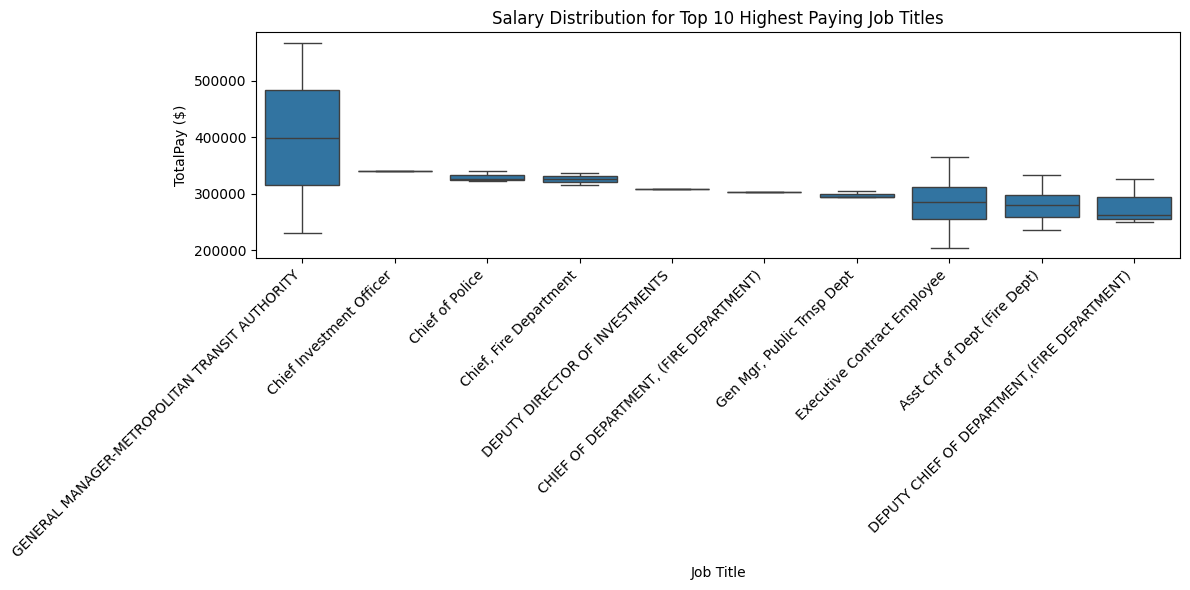

In [ ]:
# Identify the top 10 job titles by mean pay
top_job_names = df.groupby('JobTitle')['TotalPay'].mean().sort_values(ascending=False).head(10).index

# Filter the original dataframe to include only these jobs
data_plot = df[df['JobTitle'].isin(top_job_names)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='JobTitle', y='TotalPay', data=data_plot, order=top_job_names)
plt.xticks(rotation=45, ha='right')
plt.title('Salary Distribution for Top 10 Highest Paying Job Titles')
plt.ylabel('TotalPay ($)')
plt.xlabel('Job Title')
plt.tight_layout()
plt.show()

In [ ]:
# Which year had the highest average payroll cost?
print("\nAverage Payroll Cost Per Year:\n")
df.groupby('Year')['TotalPayBenefits'].mean()


Average Payroll Cost Per Year:



,TotalPayBenefits
Year,
2011,71744.103871
2012,100553.229232
2013,102357.050104
2014,100257.734862


In [ ]:
# TotalPayBenefits over years
print("\nTotal Payroll Cost Per Year:\n")
df.groupby('Year')['TotalPayBenefits'].sum()


Total Payroll Cost Per Year:



,TotalPayBenefits
Year,
2011,2.594195e+09
2012,3.696940e+09
2013,3.849239e+09
2014,3.822126e+09


In [ ]:
# who relies on overtime more than the base salary
df['OvertimeRatio'] = df['OvertimePay'] / df['TotalPay']

# Jobs Most Dependent on Overtime
print("\nTop 10 Job Titles Most Dependent on Overtime:\n")
df.groupby('JobTitle')['OvertimeRatio'] \
  .mean() \
  .sort_values(ascending=False) \
  .head(10)


Top 10 Job Titles Most Dependent on Overtime:



,OvertimeRatio
JobTitle,
Wire Rope Cable Maint Sprv,0.407185
SUPERVISING PARTS STOREKEEPER,0.344239
Junior Clerk,0.337503
Trnst Power Line Wrk Sprv 2,0.334794
Municipal Stadium Groundskpr,0.333692
WIRE ROPE CABLE MAINTENANCE SUPERVISOR,0.331439
TRACK MAINTENANCE WORKER SUPERVISOR I,0.321126
JUNIOR CLERK,0.319897
Track Maint Wrk Sprv 1,0.318666


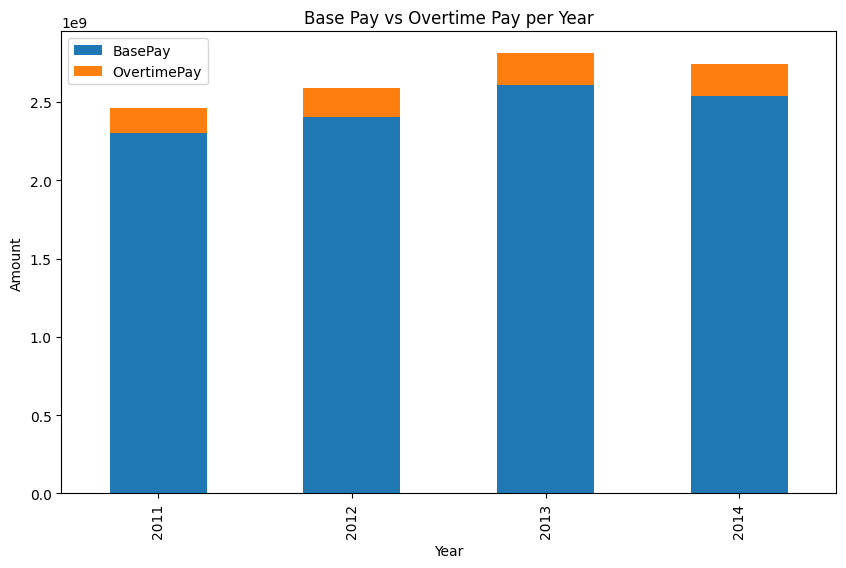

In [ ]:
# Payroll composition per year
ot_per_year = df.groupby('Year')[['BasePay','OvertimePay']].sum()
ot_per_year.plot(kind='bar', stacked=True, figsize=(10,6), title='Base Pay vs Overtime Pay per Year')
plt.ylabel('Amount')
plt.show()

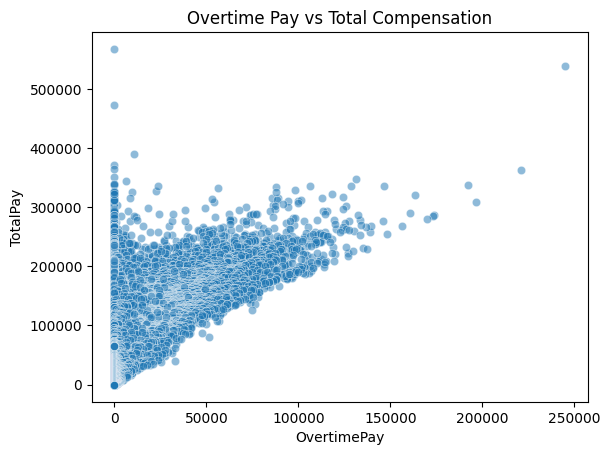

In [ ]:
# Overtime vs TotalPay
sns.scatterplot(x='OvertimePay', y='TotalPay', data=df, alpha=0.5)
plt.title('Overtime Pay vs Total Compensation')
plt.show()

In [ ]:
df.corr(numeric_only=True)


,Id,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year
Id,1.000000,-0.205030,-0.081523,-0.100419,0.285129,-0.208502,-0.089601,0.968171
BasePay,-0.205030,1.000000,0.266600,0.285475,0.651762,0.954490,0.946467,0.033302
OvertimePay,-0.081523,0.266600,1.000000,0.316595,0.226173,0.504061,0.467483,0.027870
OtherPay,-0.100419,0.285475,0.316595,1.000000,0.160344,0.473993,0.425255,-0.002515
Benefits,0.285129,0.651762,0.226173,0.160344,1.000000,0.629902,0.780772,0.461408
TotalPay,-0.208502,0.954490,0.504061,0.473993,0.629902,1.000000,0.977089,0.034181
TotalPayBenefits,-0.089601,0.946467,0.467483,0.425255,0.780772,0.977089,1.000000,0.153938
Year,0.968171,0.033302,0.027870,-0.002515,0.461408,0.034181,0.153938,1.000000


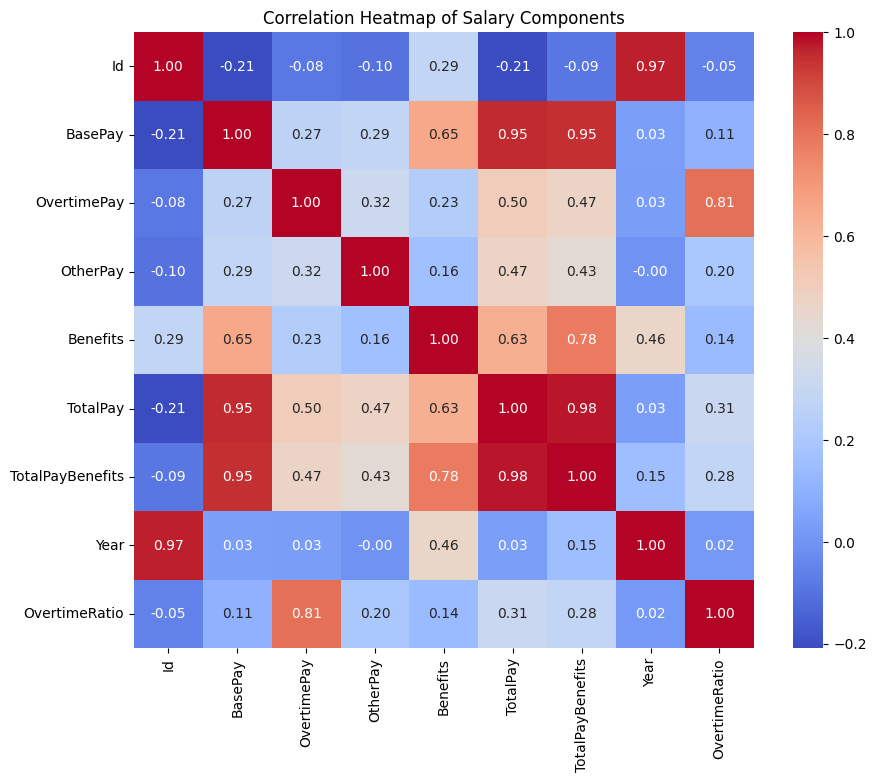

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Salary Components')
plt.show()

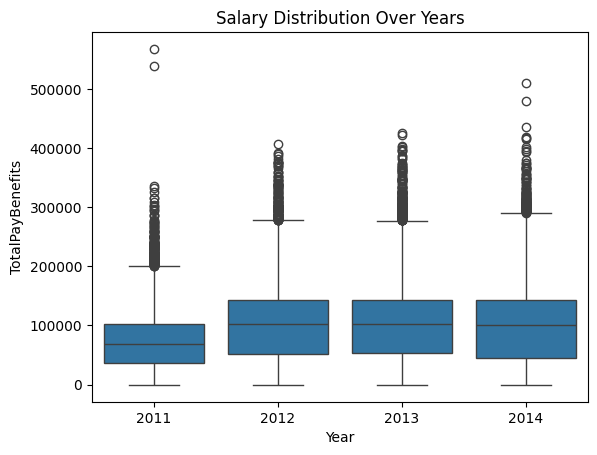

In [ ]:
# TotalPayBenefits distribution per year
sns.boxplot(x='Year', y='TotalPayBenefits', data=df)
plt.title('Salary Distribution Over Years')
plt.show()


In [ ]:
# Average benefits by employment status
print("\nAverage Benefits by Employment Status:\n")
df[df['Status'].notnull()].groupby('Status')['Benefits'].mean()


Average Benefits by Employment Status:



,Benefits
Status,
FT,35022.651762
PT,10310.986689


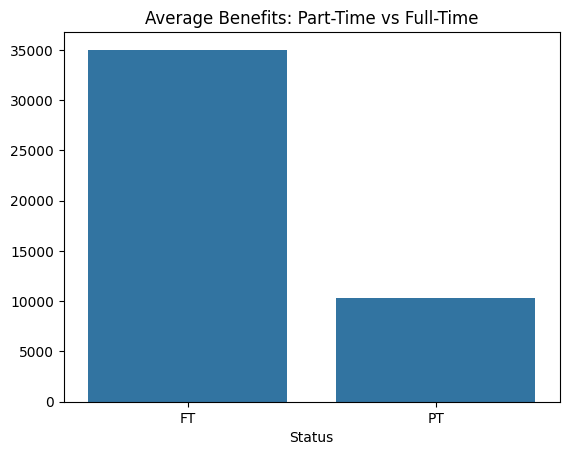

In [ ]:
# Average benefits per status
sns.barplot(x=status_benefits.index, y=status_benefits.values)
plt.title('Average Benefits: Part-Time vs Full-Time')
plt.show()

# Employee Compensation Analysis – Executive Summary

This report provides a comprehensive analysis of employee compensation using the salary dataset. It focuses on **TotalPay, TotalPayBenefits, BasePay, OvertimePay, OtherPay, Benefits, JobTitle, Year, and Status**, delivering actionable insights for payroll management, cost optimization, and workforce planning.

**Executive Summary:**  
Overall payroll costs have increased over 2011–2014, with key roles concentrated in executive and specialized positions. Overtime dependency is high in certain operational roles, posing a risk of burnout and inefficiency. BasePay strongly predicts total compensation, allowing for accurate budget forecasting.

---

## 1. Top Paid Employees
- The top 10 highest-paid employees include senior managers, police captains, and specialized technical roles.
- **Examples:**
  - NATHANIEL FORD (GENERAL MANAGER) – TotalPay = $567,595  
  - GARY JIMENEZ (CAPTAIN III) – TotalPay = $538,909
- **Business Insight:** These employees represent a substantial portion of payroll. Close monitoring is critical to manage budget impact.  

**Note:** These outliers may result from special contracts, bonuses, or temporary assignments.

---

## 2. High-Earning Job Categories
- Highest average TotalPay is concentrated in executive or specialized roles:
  - GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY – $399,211  
  - Chief Investment Officer – $339,654
- **Business Insight:** Payroll is concentrated in a few job categories. Strategic hiring and promotion policies can significantly affect total payroll costs.

---

## 3. Payroll Costs Over Time
- **Average TotalPayBenefits per year:**
  - 2011: $71,744  
  - 2012: $100,553  
  - 2013: $102,357  
  - 2014: $100,258
- **Total payroll per year:**
  - 2011: $2.59B  
  - 2012: $3.70B  
  - 2013: $3.85B  
  - 2014: $3.82B
- **Business Insight:** Payroll costs have grown steadily.  

> **Observation:** There is a ~40% increase in average payroll from 2011 to 2012. Investigate whether this is due to city-wide policy changes, new benefits, or other structural adjustments.

---

## 4. Overtime Dependency – The Burnout Alert
- Some roles rely heavily on overtime pay:
  - Wire Rope Cable Maint Sprv – 0.407 → 40% of total pay comes from overtime  
  - SUPERVISING PARTS STOREKEEPER – 0.344  
  - Junior Clerk – 0.338  
  - Trnst Power Line Wrk Sprv 2 – 0.335  
  - Municipal Stadium Groundskpr – 0.334
- **Business Insight:** High overtime may indicate understaffing or workflow inefficiencies.  
- **Burnout Alert:** Roles like Wire Rope Cable Maint Sprv are at risk for human error or burnout due to excessive overtime. Optimizing staffing can reduce costs and operational risk.

---

## 5. Salary Composition & Correlation
- Key correlations:
  - TotalPay vs BasePay: 0.954  
  - TotalPay vs OvertimePay: 0.504  
  - TotalPayBenefits vs Benefits: 0.781
- **Business Insight:** Payroll is driven by multiple components. Managing each separately helps control total compensation.  
- **Smart Note:** The extremely high correlation (0.954) indicates **BasePay is a reliable predictor of total compensation**, allowing accurate budget forecasts and minimal financial surprises.

---

## 6. Salary Distribution & Trends
- Salaries are widening over time:
  - Interquartile range (IQR) increased by ~30% from 2011 to 2014.  
  - Boxplots show spikes due to high base pay or overtime in 2013–2014.
- **Business Insight:** Monitoring salary disparities helps maintain fair compensation and employee satisfaction.

---

## 7. Benefits Allocation
- Average benefits by employment status:
  - Full-Time (FT): $35,023  
  - Part-Time (PT): $10,311 (≈3.4× lower than FT)
- **Business Insight:** Benefits are aligned with policies. Significant PT vs FT gap highlights potential areas for cost optimization or benefits restructuring.

---

## 8. Strategic Recommendations
> 1. **Monitor High-Cost Roles:** Focus on top-paid employees and high-paying job categories to manage budget impact.  
> 2. **Optimize Overtime:** Reduce overtime dependency through staffing adjustments to avoid inflated payroll costs.  
> 3. **Manage Benefits Efficiently:** Align benefits allocation with employment status for cost-effectiveness.  
> 4. **Forecast Salary Trends:** Use historical payroll data for accurate future budgeting.  
> 5. **Plan Workforce Needs:** Address roles with high overtime dependency to improve efficiency and reduce payroll waste.  
> 6. **Key Recommendation:** Every $1 increase in BasePay leads to nearly an identical increase in total financial burden. Controlling **BasePay** is the most effective lever for long-term fiscal stability.

---

## Overall Business Value
- Identifies key payroll cost drivers and high-risk roles.  
- Highlights positions with excessive overtime dependency and potential staffing inefficiencies.  
- Provides actionable insights for budgeting, compensation policies, and workforce optimization.  
- Supports data-driven decisions to maintain cost efficiency while ensuring employee satisfaction.

---
